[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fw-ai/cookbook/blob/main/training/case-studies/dpo_style/dpo_helpsteer3_sdk.ipynb)

# DPO on HelpSteer3 — pure Python SDK

Managed DPO done entirely through the **Fireworks Python SDK**
(`client.dpo_jobs`). Data prep, the DPO job, deploy, and the win-rate eval all run
through the SDK.

## Pipeline

1. Build the managed DPO dataset (`input` / `preferred_output` / `non_preferred_output`).
2. **Eval BEFORE** — base model win-rate vs the human-preferred answer.
3. `client.dpo_jobs.create(...)` and poll to completion.
4. Deploy the tuned model and **Eval AFTER**; print the before -> after delta.

## Prerequisites

```bash
pip install --pre fireworks-ai openai python-dotenv datasets nest_asyncio
pip install eval-protocol
```

`.env`: `FIREWORKS_API_KEY`, `FIREWORKS_ACCOUNT_ID`, optional `WANDB_*`.

> No firectl/cookbook. Train + deploy cells provision real GPU and **cost money**.

In [1]:
# Environment + Fireworks SDK client + repo-root path for eval_common + helpers.
import os, sys, json, time, uuid
from pathlib import Path
import dotenv

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)  # repo-root .env

# Put repo root + common/ on the path so eval_common imports from this example folder.
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / "common" / "eval_common.py").exists():
    _REPO_ROOT = _REPO_ROOT.parent
for _p in (str(_REPO_ROOT), str(_REPO_ROOT / "common"), str(Path.cwd())):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from fireworks import Fireworks, file_from_path

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing from .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
assert ACCOUNT_ID, "FIREWORKS_ACCOUNT_ID missing from .env"

client = Fireworks()  # reads FIREWORKS_API_KEY + FIREWORKS_ACCOUNT_ID from env

def wait_until(get_fn, ok, bad, label, every=30, tries=240):
    obj = None
    for i in range(tries):
        obj = get_fn()
        st = getattr(obj, "state", None)
        print(f"[{label}] {i+1:03d} state={st}")
        if st in ok:
            return obj
        if st in bad:
            raise RuntimeError(f"{label} failed: state={st}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish after {tries} polls")

def upload_dataset(ds_id, path, fmt="CHAT"):
    n_examples = sum(1 for line in open(path, encoding="utf-8") if line.strip())
    client.datasets.create(dataset_id=ds_id, dataset={"format": fmt, "example_count": n_examples})
    client.datasets.upload(dataset_id=ds_id, file=file_from_path(path))
    wait_until(lambda: client.datasets.get(ds_id), {"READY"}, {"STATE_UNSPECIFIED"},
               "dataset", every=3, tries=200)
    return f"accounts/{ACCOUNT_ID}/datasets/{ds_id}"

print("SDK client ready. account:", ACCOUNT_ID)

SDK client ready. account: pyroworks


In [2]:
# CONFIG
# qwen3-8b: small, tunable, non-reasoning-friendly (with /no_think). DPO on a reasoning/
# "harmony" base (e.g. gpt-oss) tends to fight its native format and regress. qwen3-8b isn't
# serverless here, so the base eval deploys it on-demand, scores it, and tears it down.
BASE_MODEL = "accounts/fireworks/models/qwen3-8b"
JUDGE_MODEL = "accounts/fireworks/routers/glm-5p2-fast"   # serverless judge (different family => no self-bias)

# Data
LANGUAGE = "english"
MAX_TRAIN = 2000
MAX_HOLDOUT = 200

# DPO knobs. epochs=1 barely moved the policy on qwen3-8b (flat loss, tuned==base); 3 gives the
# preference signal room to take without over-shifting. (gpt-oss over-shifted at high epochs, but
# that was a reasoning-base artifact.) Bump LEARNING_RATE to 2e-5 if the loss stays flat.
LEARNING_RATE = 1e-5
LORA_RANK = 16
EPOCHS = 3
# NOTE: we don't set max_context_length or batch_size — the server picks consistent
# defaults (batch must be >= context, so overriding one alone can conflict).
# DPO beta lives server-side under loss_config.dpo.beta (default 0.1) and is NOT
# exposed by the alpha SDK's typed loss config, so we leave it at the default.

# Eval
N_EVAL = 60
ACCELERATOR_TYPE = "NVIDIA_H200_141GB"   # SDK deploy needs an explicit accelerator (unlike firectl)

DATASET_ID = f"helpsteer3-dpo-sdk-{uuid.uuid4().hex[:6]}"
OUTPUT_MODEL_ID = f"qwen3-8b-dpo-sdk-{uuid.uuid4().hex[:6]}"   # bare id
DEPLOYMENT_ID = f"dpo-sdk-{uuid.uuid4().hex[:6]}"
print("dataset_id:", DATASET_ID, "| output_model_id:", OUTPUT_MODEL_ID)

dataset_id: helpsteer3-dpo-sdk-127874 | output_model_id: qwen3-8b-dpo-sdk-088590


## 1. Build the preference dataset (managed DPO schema)

Map `nvidia/HelpSteer3` into
`{input, preferred_output, non_preferred_output}`, drop ties, and keep only
single-turn prompts (managed DPO constraint).

**Eval carve-out:** we train on HelpSteer3's `train` split and hold out its separate
`validation` split for scoring — a genuine, never-trained-on validation set for the
before/after win-rate. (Managed DPO doesn't expose a server-side auto-carveout like SFT does,
so we carve out the holdout ourselves here.)

In [3]:
# Data prep.
from datasets import load_dataset

TRAIN_FILE = "./helpsteer3_dpo_train.jsonl"
HOLDOUT_FILE = "./helpsteer3_dpo_holdout.jsonl"

def to_managed_row(ex):
    pref = ex.get("overall_preference")
    if pref is None or pref == 0:
        return None                                   # tie -> no signal
    ctx = ex.get("context") or []
    if not isinstance(ctx, list) or not ctx:
        return None
    if any(m.get("role") == "assistant" for m in ctx):
        return None                                   # managed DPO is single-turn
    preferred, non_preferred = ((ex["response1"], ex["response2"]) if pref < 0
                                else (ex["response2"], ex["response1"]))
    return {"input": {"messages": ctx},
            "preferred_output":     [{"role": "assistant", "content": preferred}],
            "non_preferred_output": [{"role": "assistant", "content": non_preferred}]}

def build_dpo(language, max_train, max_holdout):
    ds = load_dataset("nvidia/HelpSteer3", "preference")
    def dump(split, path, limit):
        n = 0
        with open(path, "w", encoding="utf-8") as f:
            for ex in ds[split]:
                if language and ex.get("language", "english") != language:
                    continue
                row = to_managed_row(ex)
                if row is None:
                    continue
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
                n += 1
                if limit and n >= limit:
                    break
        print(f"[{split}] wrote {n} single-turn rows -> {path}")
    dump("train", TRAIN_FILE, max_train)
    dump("validation", HOLDOUT_FILE, max_holdout)

if not (Path(TRAIN_FILE).exists() and Path(HOLDOUT_FILE).exists()):
    build_dpo(LANGUAGE, MAX_TRAIN, MAX_HOLDOUT)
else:
    print("Reusing existing JSONL (delete to rebuild).")

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

train_rows = load_jsonl(TRAIN_FILE)
holdout = load_jsonl(HOLDOUT_FILE)
print(f"train={len(train_rows)}  holdout={len(holdout)}")

  from .autonotebook import tqdm as notebook_tqdm


Reusing existing JSONL (delete to rebuild).
train=2000  holdout=200


## 2. Eval BEFORE (baseline win-rate)

Win-rate metric via `eval_common`: how often the base model's answer beats the human-preferred
one (position-bias-guarded LLM judge). `qwen3-8b` isn't serverless on this account, so the base
is **deployed on-demand, scored, and torn down** (`win_rate_deployed`). Generation uses
`/no_think` and `temperature=0.0` for direct, low-noise answers.

In [4]:
# Eval-before via eval-protocol: single-turn rollout + a pairwise-judge reward (win-rate).
from ep_eval import single_turn_eval, EvaluationRow, Message, EvaluateResult, final_text
from eval_common import fw_client, pairwise_judge, strip_think

_judge_client = fw_client(os.getenv("FIREWORKS_API_KEY", ""))

def build_rows(rows_src, n):
    """managed-DPO rows -> EvaluationRows: the prompt messages + preferred answer as ground_truth.
    We prepend a `/no_think` system turn so qwen3 answers directly (no reasoning channel)."""
    out = []
    for r in rows_src[:n]:
        msgs = [Message(role="system", content="/no_think")]
        msgs += [Message(role=m["role"], content=m["content"]) for m in r["input"]["messages"]]
        out.append(EvaluationRow(messages=msgs, ground_truth=r["preferred_output"][0]["content"]))
    return out

async def winrate_reward(row: EvaluationRow) -> EvaluationRow:
    """1.0 if the judge prefers the model's answer over the human-preferred one."""
    ctx = [{"role": m.role, "content": m.content} for m in row.messages[:-1]]   # prompt (drop model answer)
    pred = strip_think(final_text(row))
    gold = str(row.ground_truth or "")
    verdict = pairwise_judge(_judge_client, JUDGE_MODEL, ctx, a=pred, b=gold)
    row.evaluation_result = EvaluateResult(score=1.0 if verdict == "A" else 0.0, reason=f"verdict={verdict}")
    return row

def dpo_win_rate(model, n=N_EVAL):
    # single_turn_eval mutates rows (appends the model answer), so build a fresh set each call.
    # temperature=0.0 to cut eval noise (win-rate vs curated human answers is jumpy).
    mean, _ = single_turn_eval(build_rows(holdout, n), model, winrate_reward, max_tokens=1024, temperature=0.0)
    return mean


def win_rate_deployed(model_resource, label, n=N_EVAL):
    """Deploy a (non-serverless) model on-demand, score win-rate, then DELETE the deployment.
    Used for the base model since qwen3-8b isn't serverless on this account."""
    did = f"dpoeval-{label}-{uuid.uuid4().hex[:6]}"
    dep = client.deployments.create(base_model=model_resource, deployment_id=did,
                                    accelerator_type=ACCELERATOR_TYPE,
                                    min_replica_count=1, max_replica_count=1)
    d_id = dep.name.split("/")[-1]
    try:
        wait_until(lambda: client.deployments.get(d_id), {"READY"}, {"FAILED"},
                   f"deploy-{label}", every=15, tries=160)
        return dpo_win_rate(f"accounts/{ACCOUNT_ID}/deployments/{d_id}", n)
    finally:
        try:
            client.deployments.delete(d_id, ignore_checks=True)
            print(f"[{label}] deployment {d_id} deleted")
        except Exception:  # noqa: BLE001
            try:
                client.deployments.scale(d_id, replica_count=0)
                print(f"[{label}] scaled to 0 (delete blocked): {d_id}")
            except Exception as e2:  # noqa: BLE001
                print(f"[{label}] teardown skip: {str(e2)[:100]}")


print(f"Scoring BASE model ({BASE_MODEL}) win-rate on {min(N_EVAL, len(holdout))} prompts (deploy -> eval -> teardown)...")
before = win_rate_deployed(BASE_MODEL, "base")
print(f"BEFORE win-rate: {before:.2%}")

  class TaskDefinitionModel(BaseModel):


Scoring BASE model (accounts/fireworks/models/qwen3-8b) win-rate on 60 prompts (deploy -> eval -> teardown)...
[deploy-base] 001 state=CREATING
[deploy-base] 002 state=CREATING
[deploy-base] 003 state=CREATING
[deploy-base] 004 state=CREATING
[deploy-base] 005 state=CREATING
[deploy-base] 006 state=CREATING
[deploy-base] 007 state=CREATING
[deploy-base] 008 state=CREATING
[deploy-base] 009 state=CREATING
[deploy-base] 010 state=CREATING
[deploy-base] 011 state=CREATING
[deploy-base] 012 state=CREATING
[deploy-base] 013 state=CREATING
[deploy-base] 014 state=CREATING
[deploy-base] 015 state=CREATING
[deploy-base] 016 state=CREATING
[deploy-base] 017 state=CREATING
[deploy-base] 018 state=CREATING
[deploy-base] 019 state=CREATING
[deploy-base] 020 state=CREATING
[deploy-base] 021 state=CREATING
[deploy-base] 022 state=CREATING
[deploy-base] 023 state=READY
[base] deployment dpoeval-base-2ab90b deleted
BEFORE win-rate: 5.00%


## 3. Fine-tune with DPO (GO LIVE)

Upload the preference dataset, then `client.dpo_jobs.create(...)` runs the managed
DPO job — the server provisions the trainer + frozen reference, optimizes the
preference loss, and promotes the result. We poll to `JOB_STATE_COMPLETED`.

**This costs money and GPU quota.**

In [ ]:
# Upload dataset + create the DPO job via the SDK + poll.
dataset_name = upload_dataset(DATASET_ID, TRAIN_FILE, fmt="CHAT")
print("dataset:", dataset_name)

wandb_config = None
if os.getenv("WANDB_API_KEY") and os.getenv("WANDB_ENTITY"):
    wandb_config = {"enabled": True, "api_key": os.getenv("WANDB_API_KEY"),
                    "entity": os.getenv("WANDB_ENTITY"),
                    "project": os.getenv("WANDB_PROJECT", "dpo-helpsteer3")}

job = client.dpo_jobs.create(
    dataset=dataset_name,
    training_config={
        "baseModel": BASE_MODEL,
        "outputModel": f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}",  # SDK wants the full resource path
        "loraRank": LORA_RANK,
        "epochs": EPOCHS,
        "learningRate": LEARNING_RATE,
    },
    loss_config={"method": "DPO"},   # beta uses the server default (dpo.beta=0.1); not exposed in the typed SDK config
    **({"wandb_config": wandb_config} if wandb_config else {}),
)
job_id = job.name.split("/")[-1]
print("DPO job:", job.name)
wait_until(lambda: client.dpo_jobs.get(job_id),
          {"JOB_STATE_COMPLETED"}, {"JOB_STATE_FAILED", "JOB_STATE_CANCELLED"}, "dpo")
TUNED_MODEL_NAME = f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}"
print("Tuned model:", TUNED_MODEL_NAME)

DPO job: accounts/pyroworks/dpoJobs/ckg50bapvtvn4ghu
[dpo] 001 state=JOB_STATE_COMPLETED
Tuned model: accounts/pyroworks/models/qwen3-8b-dpo-sdk-088590


## 4. Deploy the tuned model

Stand up an on-demand deployment of the DPO'd model so we can score it, addressed as
`accounts/<account>/deployments/<id>`.

In [8]:
# Deploy the tuned model on-demand and wait for READY.
dep = client.deployments.create(
    base_model=TUNED_MODEL_NAME,
    deployment_id=DEPLOYMENT_ID,
    accelerator_type=ACCELERATOR_TYPE,
    min_replica_count=1,
    max_replica_count=1,
)
dep_id = dep.name.split("/")[-1]
wait_until(lambda: client.deployments.get(dep_id), {"READY"}, {"FAILED"}, "deploy", every=15, tries=160)
TUNED_INFER_MODEL = f"accounts/{ACCOUNT_ID}/deployments/{dep_id}"
print("Deployed. Infer id:", TUNED_INFER_MODEL)

[deploy] 001 state=CREATING
[deploy] 002 state=CREATING
[deploy] 003 state=CREATING
[deploy] 004 state=CREATING
[deploy] 005 state=CREATING
[deploy] 006 state=CREATING
[deploy] 007 state=CREATING
[deploy] 008 state=CREATING
[deploy] 009 state=CREATING
[deploy] 010 state=CREATING
[deploy] 011 state=CREATING
[deploy] 012 state=CREATING
[deploy] 013 state=CREATING
[deploy] 014 state=CREATING
[deploy] 015 state=CREATING
[deploy] 016 state=CREATING
[deploy] 017 state=CREATING
[deploy] 018 state=CREATING
[deploy] 019 state=READY
Deployed. Infer id: accounts/pyroworks/deployments/dpo-sdk-9ad902


## 5. Eval AFTER + verdict

Rerun the exact same win-rate on the tuned model and print the before -> after delta.
Success = the tuned model beats the human-preferred answers more often than the base did.

In [ ]:
# Eval AFTER + verdict.
print(f"Scoring TUNED model win-rate on {min(N_EVAL, len(holdout))} prompts...")
after = dpo_win_rate(TUNED_INFER_MODEL)

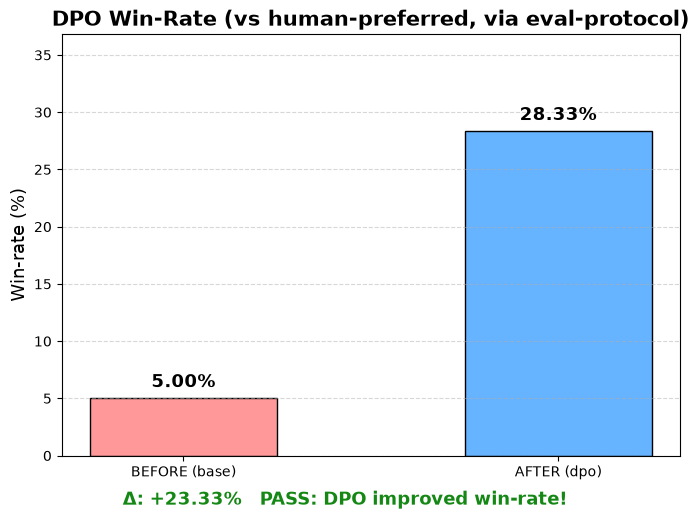

In [19]:
import matplotlib.pyplot as plt

# Create a gorgeous bar graph of win-rates before and after
labels = ['BEFORE (base)', 'AFTER (dpo)']
win_rates = [before, after]
colors = ['#ff9999','#66b3ff']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, [w*100 for w in win_rates], color=colors, width=0.5, edgecolor='black')

# Annotate bars
for bar, value in zip(bars, win_rates):
    height = bar.get_height()
    ax.annotate(f'{value:.2%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=13, fontweight='bold')

delta = after - before
plt.title("DPO Win-Rate (vs human-preferred, via eval-protocol)", fontsize=15, fontweight='bold')
plt.ylabel("Win-rate (%)", fontsize=13)
plt.ylim(0, max(win_rates)*130)
plt.grid(axis='y', linestyle='--', alpha=0.5)

result_text = (
    f"Δ: {delta:+.2%}   "
    + ("PASS: DPO improved win-rate!" if delta > 0 else "NO IMPROVEMENT: try more pairs or more epochs.")
)
plt.figtext(0.5, -.02, result_text, wrap=True, ha='center', fontsize=13, fontweight='bold', color="#148714" if delta > 0 else "#d62728")

plt.tight_layout()
plt.show()

## Cleanup — tear down the deployment

The tuned model's deployment stays up after eval. Run this to delete it once you're
done, so it stops billing.

In [10]:
# Tear down this notebook's deployment (safe to re-run).
# Fireworks blocks deleting a deployment that got traffic in the last hour, so if delete
# is refused we scale it to 0 replicas (stops billing now; delete later once the cooldown passes).
def _teardown(dep_id):
    try:
        client.deployments.delete(dep_id, ignore_checks=True)   # ignore_checks bypasses the recent-traffic guard
        print("deleted deployment:", dep_id)
    except Exception as e:  # noqa: BLE001
        try:
            client.deployments.scale(dep_id, replica_count=0)
            print(f"scaled to 0 (delete blocked): {dep_id}")
        except Exception as e2:  # noqa: BLE001
            print(f"skip {dep_id}: {str(e2)[:120]}")

for _dep in [globals().get("DEPLOYMENT_ID")]:
    if _dep:
        _teardown(_dep)

deleted deployment: dpo-sdk-9ad902
